In [41]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import os


In [14]:
df=pd.read_excel("../DataSets/Credir_Card_Bank.xlsx")

In [15]:
df

,Customer_ID,Age,Gender,Employment_Type,Occupation,Monthly_Income,Annual_Income,Credit_Score,Years_With_Bank,Existing_Credit_Cards,...,Credit_Utilization,Credit_History_Years,Missed_Payments,Late_Payment_Count,Number_of_Defaults,Residential_Status,PAN_Verified,KYC_Status,Fraud_Flag,Credit_Limit
0,CUST00001,41,Female,Salaried,Sales Executive,140273,1683276,811,4,4,...,34,11,0,8,0,Rent,Yes,Complete,No,1373925
1,CUST00002,23,Male,Self-Employed,Business Owner,209521,2514252,837,12,2,...,71,20,3,3,0,Own,Yes,Complete,No,1902449
2,CUST00003,45,Female,Salaried,Designer,47682,572184,679,2,6,...,88,12,5,2,0,Rent,Yes,Complete,No,1165913
3,CUST00004,39,Male,Salaried,Doctor,214966,2579592,660,5,0,...,66,4,3,5,0,Rent,Yes,Complete,No,1869491
4,CUST00005,58,Male,Self-Employed,Designer,30051,360612,589,18,0,...,70,1,4,2,0,Own,Yes,Complete,No,825275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST04996,48,Male,Salaried,Doctor,55078,660936,824,12,1,...,91,7,4,4,0,Rent,Yes,Complete,No,1156917
4996,CUST04997,59,Female,Self-Employed,Accountant,107040,1284480,840,0,1,...,28,22,1,6,0,Own,Yes,Complete,No,1458578
4997,CUST04998,26,Female,Salaried,Doctor,168754,2025048,632,19,0,...,38,11,3,1,0,Rent,Yes,Complete,No,1342610
4998,CUST04999,42,Male,Salaried,Manager,197110,2365320,734,9,2,...,15,3,2,2,0,Own,Yes,Complete,No,1868828


**Analyze Customers with Defaults**

In [16]:
default_customers = df[df['Number_of_Defaults']==1]
print("Number of Default Customers:")
print(default_customers.shape[0])
default_customers.head()

Number of Default Customers:
319


,Customer_ID,Age,Gender,Employment_Type,Occupation,Monthly_Income,Annual_Income,Credit_Score,Years_With_Bank,Existing_Credit_Cards,...,Credit_Utilization,Credit_History_Years,Missed_Payments,Late_Payment_Count,Number_of_Defaults,Residential_Status,PAN_Verified,KYC_Status,Fraud_Flag,Credit_Limit
25,CUST00026,31,Female,Salaried,Doctor,141177,1694124,581,10,4,...,58,1,4,3,1,Rent,Yes,Complete,No,1073580
34,CUST00035,40,Male,Salaried,Accountant,193028,2316336,619,12,2,...,24,18,1,4,1,Rent,Yes,Complete,No,1343083
38,CUST00039,26,Female,Salaried,Software Engineer,198180,2378160,558,7,5,...,92,10,3,6,1,Own,Yes,Complete,No,1431741
39,CUST00040,43,Female,Salaried,Business Owner,117988,1415856,579,8,4,...,41,0,0,1,1,Own,Yes,Complete,No,1152028
92,CUST00093,49,Male,Self-Employed,Designer,164812,1977744,571,11,5,...,46,8,3,3,1,Own,Yes,Complete,No,1372071


In [43]:
# Create a dedicated dataframe for defaulters
defaulters_df = df[df['Number_of_Defaults'] > 0]

# Compare summary metrics (e.g., income, loan amount, credit score, age) between groups
df.groupby('Number_of_Defaults').describe() # or .mean()

Age                                                \
                     count       mean        std   min   25%   50%   75%   
Number_of_Defaults                                                         
0                   4681.0  40.549242  11.510817  21.0  30.0  41.0  50.0   
1                    319.0  40.347962  11.736946  21.0  30.0  40.0  50.0   

                         Monthly_Income                 ... Credit_Limit  \
                     max          count           mean  ...          75%   
Number_of_Defaults                                      ...                
0                   60.0         4681.0  136775.660756  ...    1666477.0   
1                   60.0          319.0  142523.974922  ...    1325768.5   

                              default_payment_next_month                      \
                          max                      count mean  std  min  25%   
Number_of_Defaults                                                             
0                   2212273.0                     4681.0  0.0  0.0  0.0  0.0   
1                   1699778.0                      319.0  1.0  0.0  1.0  1.0   

                                   
                    50%  75%  max  
Number_of_Defaults                 
0                   0.0  0.0  0.0  
1                   1.0  1.0  1.0  

[2 rows x 160 columns]

Occupation
Accountant           6.074766
Business Owner       6.271777
Designer             6.605223
Doctor               6.969206
Manager              6.677796
Sales Executive      6.174699
Software Engineer    6.870229
Teacher              5.351171
Name: Number_of_Defaults, dtype: float64


C:\Users\Dhanashree\AppData\Local\Temp\ipykernel_2336\665153813.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sb.barplot(x='Occupation', y='Number_of_Defaults', data=df, ci=None)


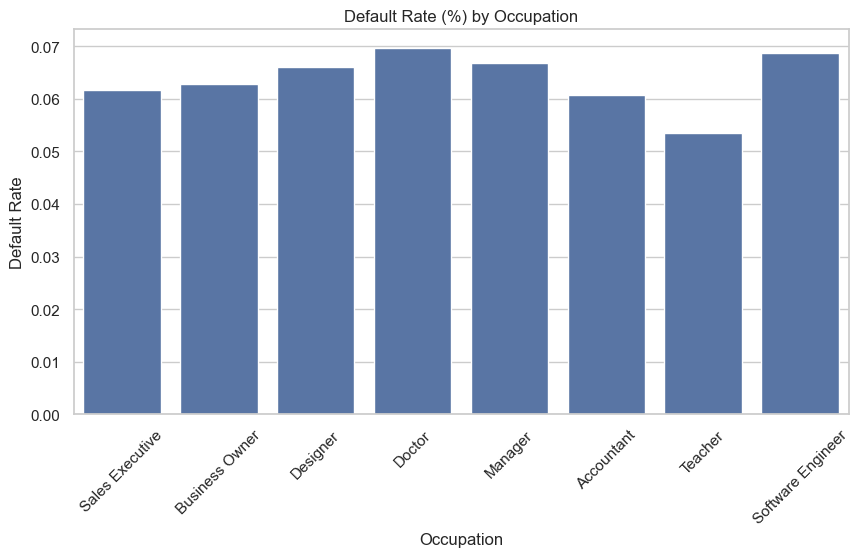

C:\Users\Dhanashree\AppData\Local\Temp\ipykernel_2336\665153813.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_risk = df.groupby('Age_Group')['Number_of_Defaults'].mean() * 100
C:\Users\Dhanashree\AppData\Local\Temp\ipykernel_2336\665153813.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sb.barplot(x='Age_Group', y='Number_of_Defaults', data=df, ci=None)


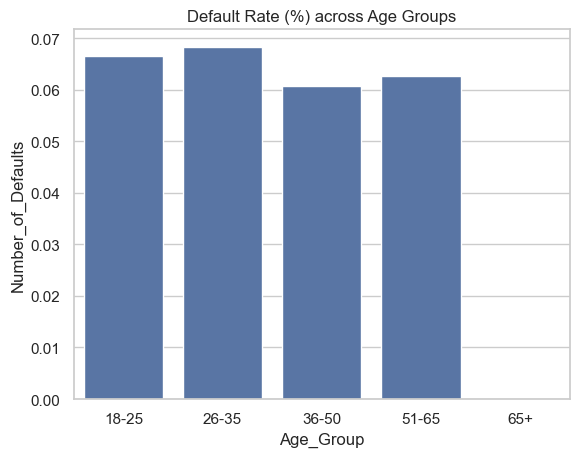

In [44]:
# Default rate by Occupation
occupation_risk = df.groupby('Occupation')['Number_of_Defaults'].mean() * 100
print(occupation_risk)

# Plotting Risk by Occupation
plt.figure(figsize=(10, 5))
sb.barplot(x='Occupation', y='Number_of_Defaults', data=df, ci=None)
plt.title("Default Rate (%) by Occupation")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

# Default rate by Age Group
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 50, 65, 100], labels=['18-25', '26-35', '36-50', '51-65', '65+'])
age_risk = df.groupby('Age_Group')['Number_of_Defaults'].mean() * 100

sb.barplot(x='Age_Group', y='Number_of_Defaults', data=df, ci=None)
plt.title("Default Rate (%) across Age Groups")
plt.show()

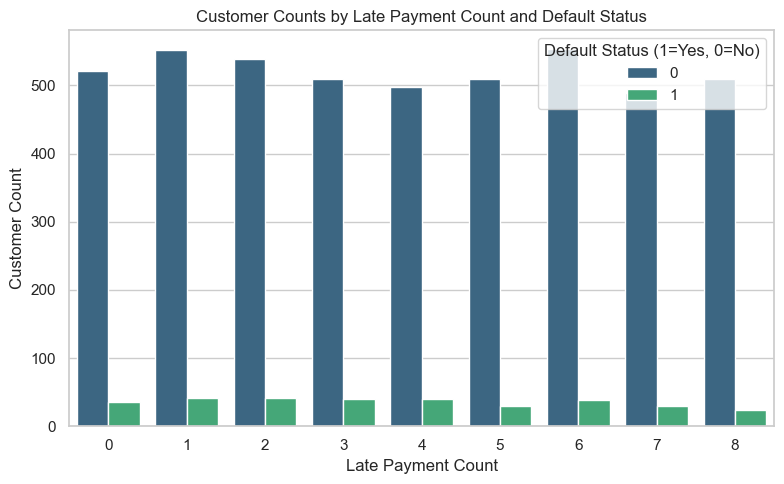

In [79]:
plt.figure(figsize=(8, 5))
sb.countplot(x='Late_Payment_Count', hue='default_payment_next_month', data=df, palette='viridis')
plt.title("Customer Counts by Late Payment Count and Default Status")
plt.xlabel("Late Payment Count")
plt.ylabel("Customer Count")
plt.legend(title="Default Status (1=Yes, 0=No)")
plt.tight_layout()
plt.show()

In [49]:
default_rate = df['Number_of_Defaults'].value_counts(normalize=True)*100
print(default_rate)

Number_of_Defaults
0    93.62
1     6.38
Name: proportion, dtype: float64


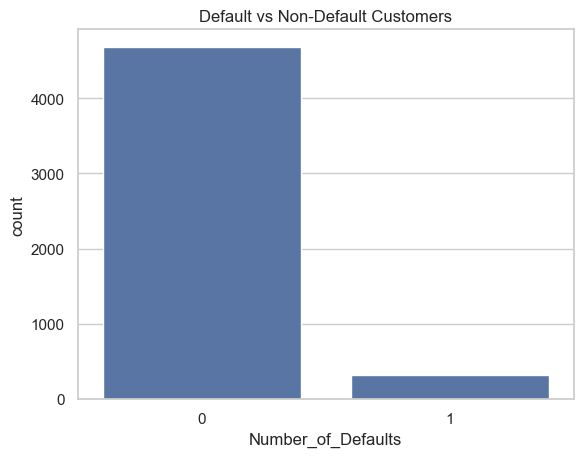

In [50]:
sb.countplot(x='Number_of_Defaults', data=df)
plt.title("Default vs Non-Default Customers")
plt.show()

**Analyze Missed Payments**

In [19]:
missed = df["Missed_Payments"].value_counts().sort_index()

In [51]:

df.groupby('Missed_Payments')['Number_of_Defaults'].mean() * 100

Missed_Payments
0    6.367925
1    8.189158
2    5.182568
3    6.264775
4    7.060334
5    5.178792
Name: Number_of_Defaults, dtype: float64

In [20]:
print("Missed Payments Distribution:")
print(missed)

Missed Payments Distribution:
Missed_Payments
0    848
1    867
2    849
3    846
4    779
5    811
Name: count, dtype: int64


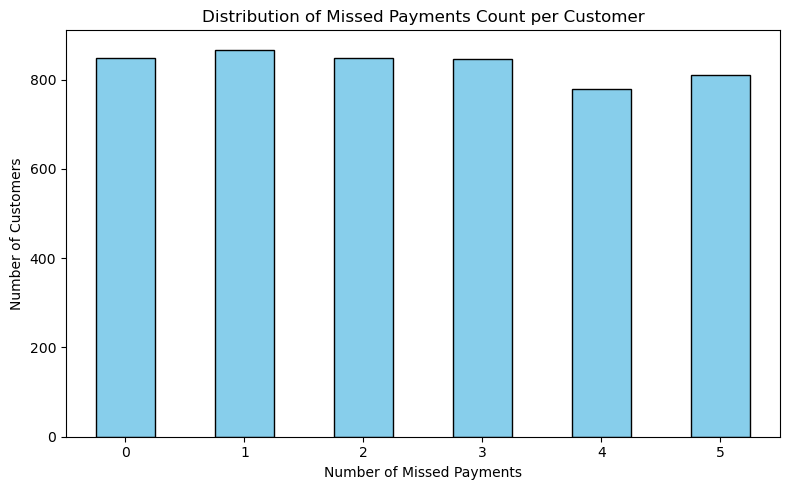

In [21]:
plt.figure(figsize=(8, 5))
missed.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribution of Missed Payments Count per Customer")
plt.xlabel("Number of Missed Payments")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Analyze Late Payment Trends**

In [22]:
avg_late_payments = df["Late_Payment_Count"].mean()
print(f"Average Late Payments per Customer: {avg_late_payments:.2f}")


late_payment_dist = df["Late_Payment_Count"].value_counts().sort_index()
print("\nDistribution of Late Payment Counts:")
print(late_payment_dist)

Average Late Payments per Customer: 3.94

Distribution of Late Payment Counts:
Late_Payment_Count
0    556
1    593
2    580
3    549
4    538
5    539
6    592
7    519
8    534
Name: count, dtype: int64


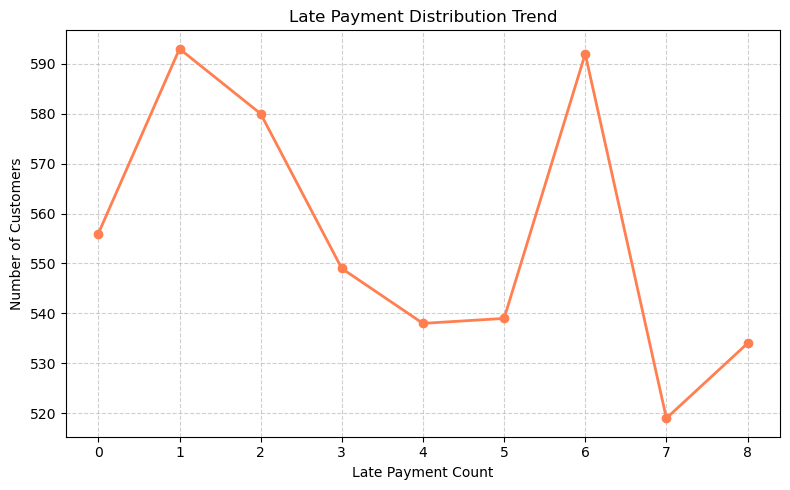

In [23]:
plt.figure(figsize=(8, 5))
late_payment_dist.plot(marker="o", color="coral", linewidth=2)
plt.title("Late Payment Distribution Trend")
plt.xlabel("Late Payment Count")
plt.ylabel("Number of Customers")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Identify High-Risk Customer Groups**

In [24]:

df["default_payment_next_month"] = (df["Number_of_Defaults"] > 0).astype(int)

In [57]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 50, 65, 100],
    labels=["18-25", "26-35", "36-50", "51-65", "65+"],
)

In [58]:
risk_age = df.groupby('Age_Group', observed=False)['default_payment_next_month'].mean() * 100

print("Default Rate by Age Group:")
print(risk_age)

Default Rate by Age Group:
Age_Group
18-25    6.644518
26-35    6.825397
36-50    6.075013
51-65    6.265060
65+           NaN
Name: default_payment_next_month, dtype: float64


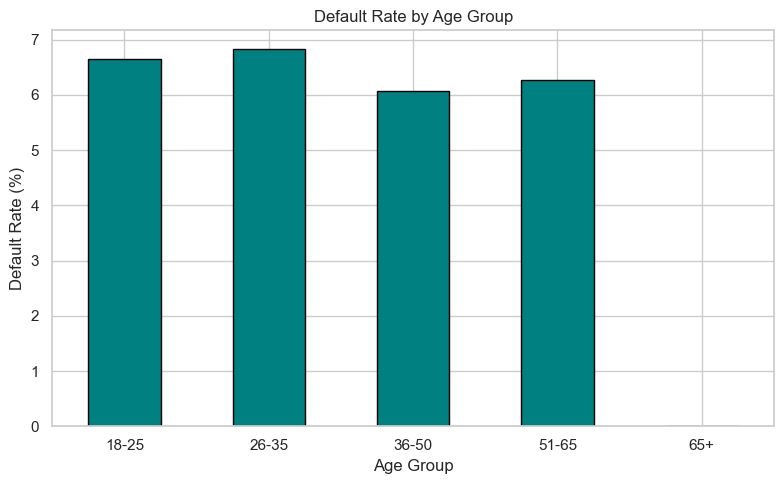

In [56]:
plt.figure(figsize=(8, 5))
risk_age.plot(kind="bar", color="teal", edgecolor="black")
plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Compare Risk Across Occupations**

In [68]:
occupation_risk = df.groupby('Occupation')['default_payment_next_month'].mean()
occupation_risk.sort_values(ascending=False)

Occupation
Doctor               0.069692
Software Engineer    0.068702
Manager              0.066778
Designer             0.066052
Business Owner       0.062718
Sales Executive      0.061747
Accountant           0.060748
Teacher              0.053512
Name: default_payment_next_month, dtype: float64

In [69]:
occupation_risk = (df.groupby("Occupation")["default_payment_next_month"].mean() * 100).sort_values()

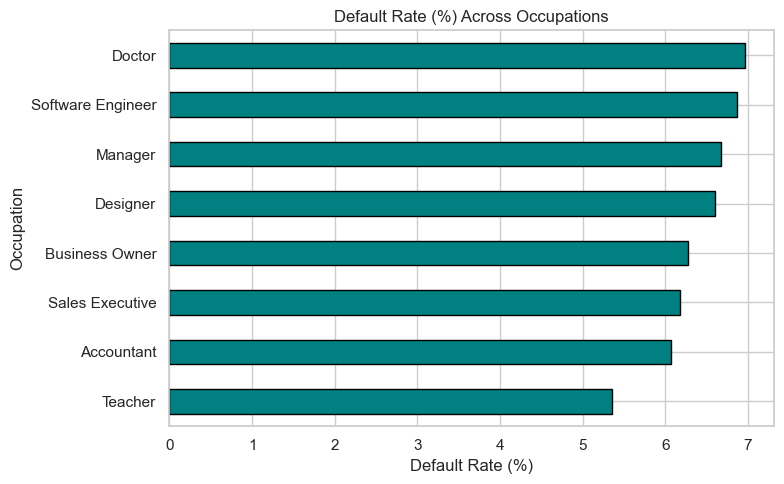

In [70]:
plt.figure(figsize=(8, 5))
occupation_risk.plot(kind="barh", color="teal", edgecolor="black")
plt.title("Default Rate (%) Across Occupations")
plt.xlabel("Default Rate (%)")
plt.ylabel("Occupation")
plt.tight_layout()
plt.show()

**Compare Risk Across Age Groups**

C:\Users\Dhanashree\AppData\Local\Temp\ipykernel_2336\2798368071.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.barplot(


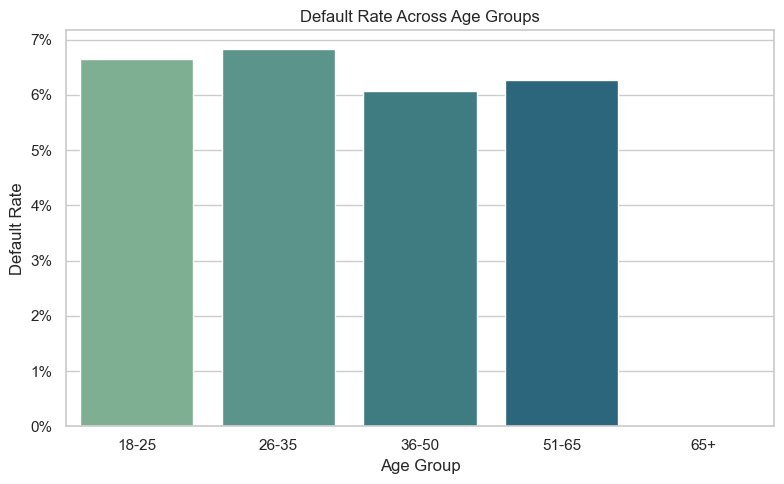

In [78]:
plt.figure(figsize=(8, 5))

ax = sb.barplot(
    x='Age_Group', 
    y='default_payment_next_month', 
    data=df, 
    errorbar=None, 
    palette='crest'
)
plt.title("Default Rate Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Default Rate")

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.tight_layout()
plt.show()

In [72]:
corr_with_target = df.corr(numeric_only=True)['default_payment_next_month']

In [73]:

corr_ranked = corr_with_target.drop(
    ['default_payment_next_month', 'Number_of_Defaults'], 
    errors='ignore'
).sort_values(ascending=False)


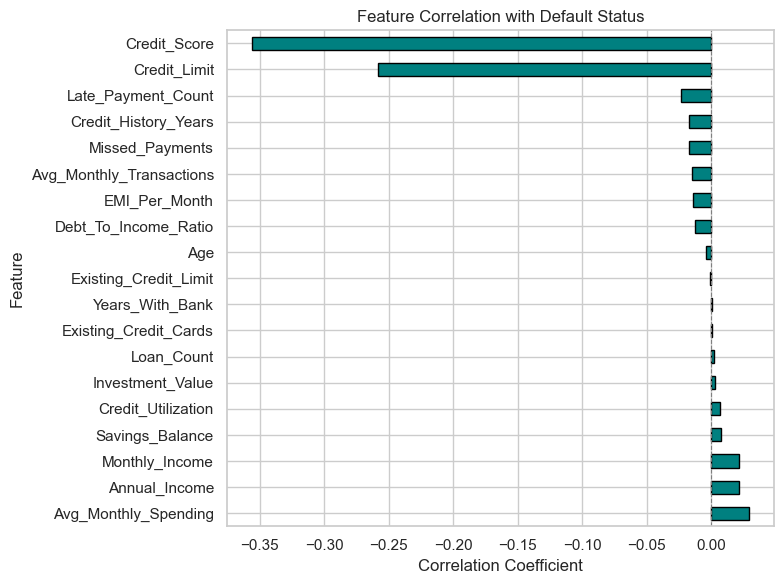

In [75]:
plt.figure(figsize=(8, 6))
corr_ranked.plot(kind='barh', color='teal', edgecolor='black')
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8) # Reference line at 0 correlation
plt.title("Feature Correlation with Default Status")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [38]:
summary = df.groupby('default_payment_next_month').mean(numeric_only=True)
summary

,Age,Monthly_Income,Annual_Income,Credit_Score,Years_With_Bank,Existing_Credit_Cards,Existing_Credit_Limit,Loan_Count,EMI_Per_Month,Debt_To_Income_Ratio,Savings_Balance,Investment_Value,Avg_Monthly_Transactions,Avg_Monthly_Spending,Credit_Utilization,Credit_History_Years,Missed_Payments,Late_Payment_Count,Number_of_Defaults,Credit_Limit
default_payment_next_month,,,,,,,,,,,,,,,,,,,,
0,40.549242,136775.660756,1.641308e+06,709.956633,10.118778,3.019868,504851.895962,2.018799,30377.390728,0.323963,753988.031404,992867.180731,131.844905,70099.117432,50.189917,12.468062,2.462294,3.956420,0.0,1.435653e+06
1,40.347962,142523.974922,1.710288e+06,584.028213,10.131661,3.028213,504056.404389,2.031348,29406.269592,0.315956,767267.658307,999502.868339,127.692790,76469.677429,50.974922,11.940439,2.344828,3.711599,1.0,1.114570e+06


C:\Users\Dhanashree\AppData\Local\Temp\ipykernel_2336\458119453.py:67: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:teal'` for the same effect.

  sb.barplot(


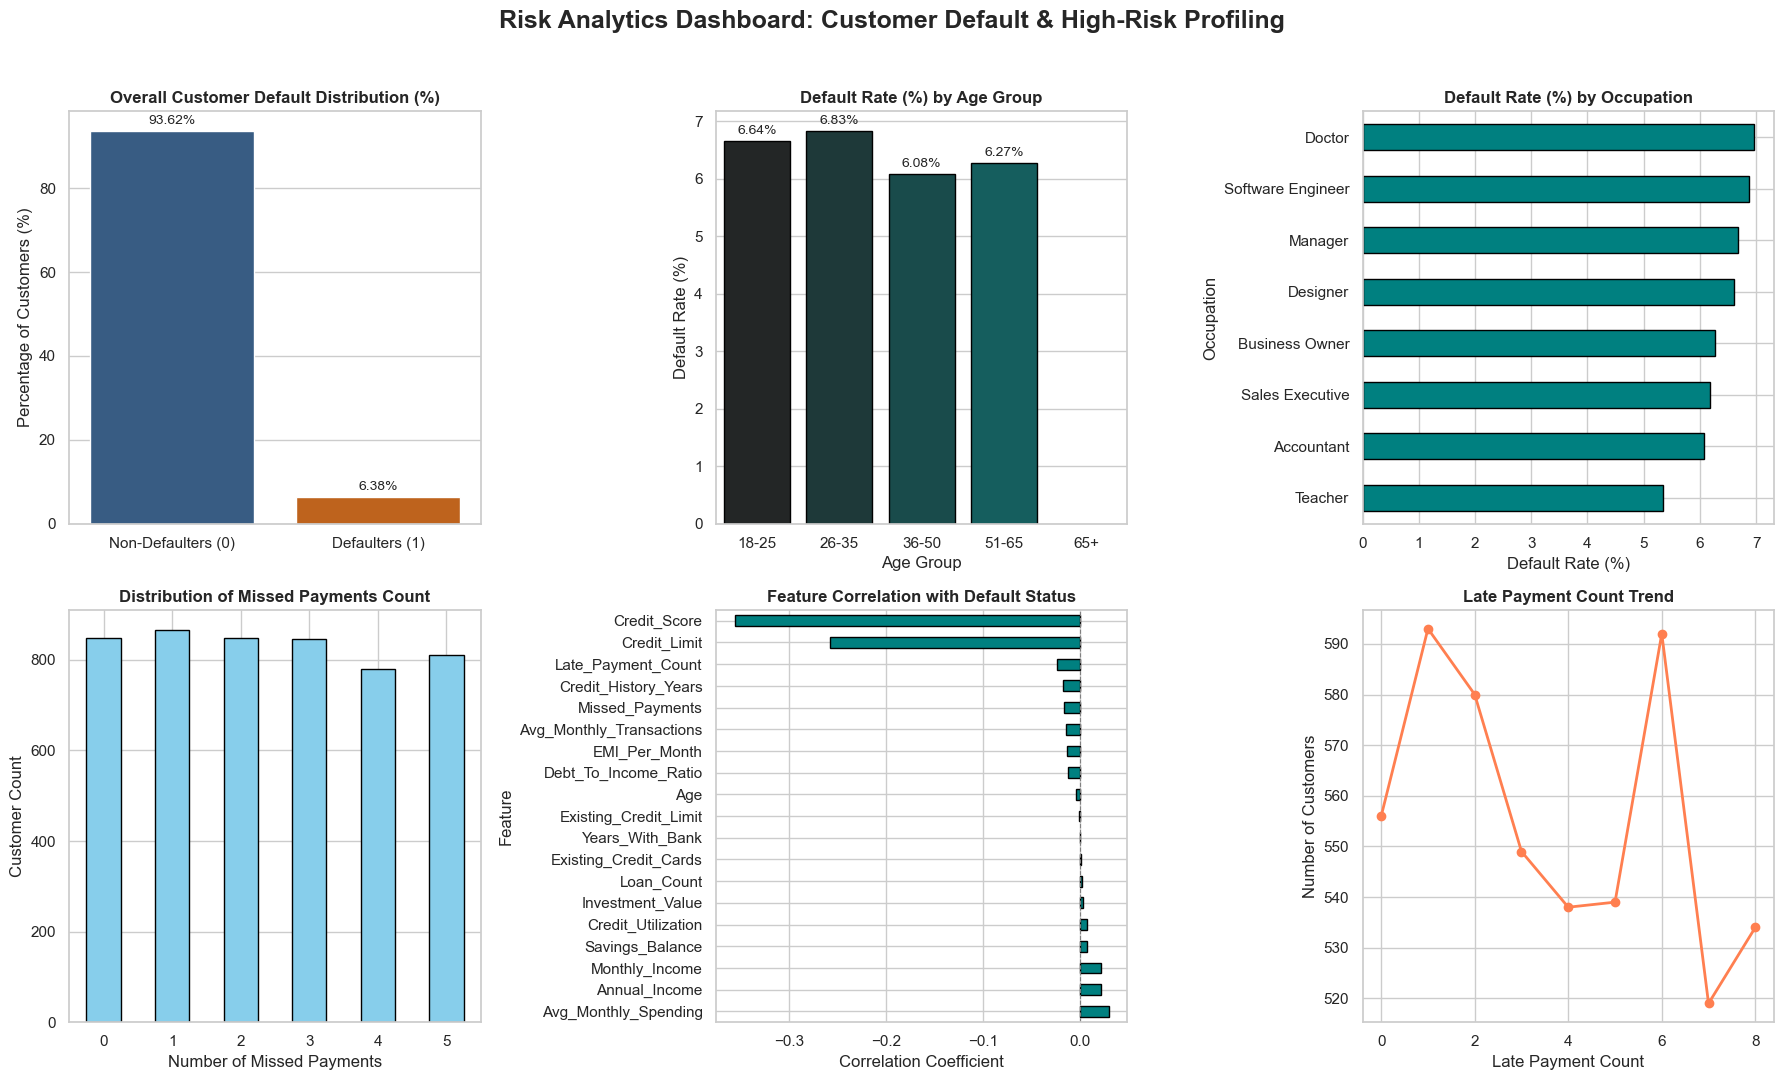

             RISK ANALYTICS SUMMARY               
Total Portfolio Size: 5,000 customers
Total Defaulted Customers: 319
Overall Default Rate: 6.38%
Average Late Payments per Customer: 3.94
--------------------------------------------------
High-Risk Flagged Segment Breakdown:
High_Risk_Flag
High Risk    3314
Standard     1686
Name: count, dtype: int64


In [80]:

# Create target variable: Binary default indicator (1 = Default, 0 = Non-Default)
df["default_payment_next_month"] = (df["Number_of_Defaults"] > 0).astype(int)

# Create Age Group bins
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 50, 65, 100],
    labels=["18-25", "26-35", "36-50", "51-65", "65+"],
)

# Define Composite High-Risk Customer Rule:
# (e.g., Credit Score < 600 OR Credit Utilization > 75% OR Missed Payments >= 3)
high_risk_condition = (
    (df["Credit_Score"] < 600)
    | (df["Credit_Utilization"] > 75)
    | (df["Missed_Payments"] >= 3)
)
df["High_Risk_Flag"] = np.where(high_risk_condition, "High Risk", "Standard")


# =============================================================================
# 2. CONSOLIDATED HIGH-RISK CUSTOMER DASHBOARD (2x3 GRID)
# =============================================================================
# Set global style
sb.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "Risk Analytics Dashboard: Customer Default & High-Risk Profiling",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

# -----------------------------------------------------------------------------
# Subplot 1: Overall Default Rate Distribution (Class Imbalance)
# -----------------------------------------------------------------------------
ax1 = axes[0, 0]
default_counts = df["default_payment_next_month"].value_counts(normalize=True) * 100
sb.barplot(
    x=["Non-Defaulters (0)", "Defaulters (1)"],
    y=default_counts.values,
    palette=["#2b5c8f", "#d95f02"],
    ax=ax1,
    hue=["Non-Defaulters (0)", "Defaulters (1)"],
    legend=False,
)
ax1.set_title("Overall Customer Default Distribution (%)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Percentage of Customers (%)")
for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )

# -----------------------------------------------------------------------------
# Subplot 2: Default Rate (%) Across Age Groups
# -----------------------------------------------------------------------------
ax2 = axes[0, 1]
risk_age = (
    df.groupby("Age_Group", observed=False)["default_payment_next_month"].mean() * 100
)
sb.barplot(
    x=risk_age.index,
    y=risk_age.values,
    color="teal",
    edgecolor="black",
    ax=ax2,
    hue=risk_age.index,
    legend=False,
)
ax2.set_title("Default Rate (%) by Age Group", fontsize=12, fontweight="bold")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Default Rate (%)")
for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(
            f"{p.get_height():.2f}%",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points",
        )

# -----------------------------------------------------------------------------
# Subplot 3: Default Rate (%) Across Occupations
# -----------------------------------------------------------------------------
ax3 = axes[0, 2]
occ_risk = (
    df.groupby("Occupation")["default_payment_next_month"].mean() * 100
).sort_values()
occ_risk.plot(kind="barh", color="teal", edgecolor="black", ax=ax3)
ax3.set_title("Default Rate (%) by Occupation", fontsize=12, fontweight="bold")
ax3.set_xlabel("Default Rate (%)")
ax3.set_ylabel("Occupation")

# -----------------------------------------------------------------------------
# Subplot 4: Distribution of Missed Payments per Customer
# -----------------------------------------------------------------------------
ax4 = axes[1, 0]
missed_counts = df["Missed_Payments"].value_counts().sort_index()
missed_counts.plot(kind="bar", color="skyblue", edgecolor="black", ax=ax4)
ax4.set_title("Distribution of Missed Payments Count", fontsize=12, fontweight="bold")
ax4.set_xlabel("Number of Missed Payments")
ax4.set_ylabel("Customer Count")
ax4.tick_params(axis="x", rotation=0)

# -----------------------------------------------------------------------------
# Subplot 5: Feature Correlations with Default Status
# -----------------------------------------------------------------------------
ax5 = axes[1, 1]
corr_with_target = df.corr(numeric_only=True)["default_payment_next_month"]
corr_ranked = corr_with_target.drop(
    ["default_payment_next_month", "Number_of_Defaults"], errors="ignore"
).sort_values(ascending=False)
corr_ranked.plot(kind="barh", color="teal", edgecolor="black", ax=ax5)
ax5.axvline(0, color="grey", linestyle="--", linewidth=0.8)
ax5.set_title("Feature Correlation with Default Status", fontsize=12, fontweight="bold")
ax5.set_xlabel("Correlation Coefficient")
ax5.set_ylabel("Feature")

# -----------------------------------------------------------------------------
# Subplot 6: Late Payment Count Distribution Trend
# -----------------------------------------------------------------------------
ax6 = axes[1, 2]
late_payment_dist = df["Late_Payment_Count"].value_counts().sort_index()
late_payment_dist.plot(marker="o", color="coral", linewidth=2, ax=ax6)
ax6.set_title("Late Payment Count Trend", fontsize=12, fontweight="bold")
ax6.set_xlabel("Late Payment Count")
ax6.set_ylabel("Number of Customers")

# Final Layout Adjustments
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# =============================================================================
# 3. PRINT EXECUTIVE SUMMARY METRICS
# =============================================================================
print("==================================================")
print("             RISK ANALYTICS SUMMARY               ")
print("==================================================")
print(f"Total Portfolio Size: {len(df):,} customers")
print(f"Total Defaulted Customers: {df['default_payment_next_month'].sum():,}")
print(f"Overall Default Rate: {df['default_payment_next_month'].mean() * 100:.2f}%")
print(f"Average Late Payments per Customer: {df['Late_Payment_Count'].mean():.2f}")
print("--------------------------------------------------")
print("High-Risk Flagged Segment Breakdown:")
print(df["High_Risk_Flag"].value_counts())
print("==================================================")
